In [1]:
## SQL Database Setup

In [3]:
import sqlite3
import pandas as pd

df = pd.read_csv('../data/clean/superstore_sales_cleaned.csv')
conn = sqlite3.connect('../data/superstore_sales.db')
df.to_sql('orders', conn, if_exists='replace', index=False)
print("Database created.")


Database created.


In [23]:
## Table Check
query = """
SELECT * 
FROM orders 
LIMIT 5;"""
check = pd.read_sql_query(query, conn)
print(check)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...     Sales  \
0      Claire Gute   Consumer  United States        Henderson  ...  261.9600   
1      Claire Gute   Consumer  United States        Henderson  ...  731.9400   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   14.6200   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  957.5775   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   22.3680   

   Quantity Discount    Profit O

In [24]:
## Total Orders
query = """
SELECT COUNT(*) AS total_orders 
FROM orders;"""
total_orders = pd.read_sql_query(query, conn)
print(total_orders)

   total_orders
0          9994


In [25]:
## Total Revenue
query = """
SELECT FORMAT(SUM(Sales), 2) AS total_revenue 
FROM orders;"""
total_revenue = pd.read_sql_query(query, conn)
print(total_revenue)

      total_revenue
0  2297200.86029995


In [29]:
## Revenue by Category
query = """
SELECT Category, 
FORMAT(SUM(Sales), 2) AS revenue
FROM orders
GROUP BY Category 
ORDER BY revenue DESC;"""
revenue_by_category = pd.read_sql_query(query, conn)
print(revenue_by_category)

          Category           revenue
0       Technology  836154.032999997
1        Furniture       741999.7953
2  Office Supplies  719047.032000003


In [30]:
## Profit by Category
query = """
SELECT Category, 
FORMAT(SUM(Profit), 2) AS total_profit
FROM orders 
GROUP BY Category 
ORDER BY total_profit DESC;"""
profit_by_category = pd.read_sql_query(query, conn)
print(profit_by_category)

          Category total_profit
0        Furniture   18451.2728
1       Technology  145454.9481
2  Office Supplies  122490.8008


In [31]:
## True Profit Margins
query = """
SELECT Category,
FORMAT(SUM(Profit), 2) * 100 / SUM(Sales) AS profit_margin
FROM orders
GROUP BY Category
ORDER BY profit_margin DESC;"""
profit_margins = pd.read_sql_query(query, conn)
print(profit_margins)

          Category  profit_margin
0       Technology      17.395712
1  Office Supplies      17.035158
2        Furniture       2.486695


In [32]:
## Loss Making Orders
query = """
SELECT COUNT(*) AS loss_orders
FROM orders
WHERE Profit < 0;"""
loss_orders = pd.read_sql_query(query, conn)
print(loss_orders)

   loss_orders
0         1871


In [38]:
## Discount Impact
query = """
SELECT Discount * 100 AS Discount_Percentage,
FORMAT(AVG(Profit), 2) AS avg_profit
FROM orders
GROUP BY Discount
ORDER BY Discount;"""
discount_impact = pd.read_sql_query(query, conn)
discount_impact = df.groupby("Discount")["Profit"].mean()
print(discount_impact)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


In [39]:
## Visualizations
print(discount_impact.head())

Discount
0.00    66.900292
0.10    96.055074
0.15    27.288298
0.20    24.702572
0.30   -45.679636
Name: Profit, dtype: float64


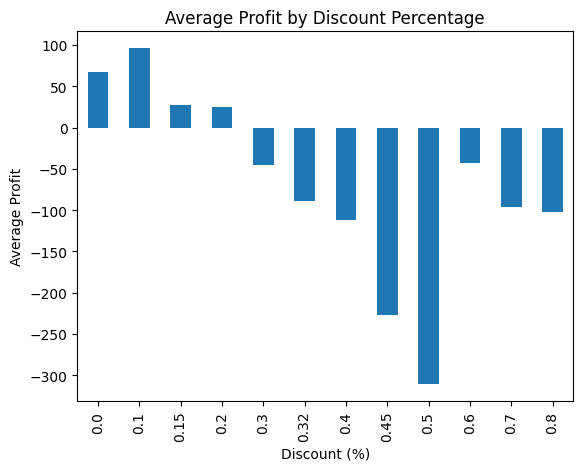

In [41]:
import matplotlib.pyplot as plt

discount_impact.plot(kind='bar')
plt.xlabel('Discount (%)')
plt.ylabel('Average Profit')
plt.title('Average Profit by Discount Percentage')

plt.show()

Discount vs Profit Analysis

Key Findings:
    Orders with 0–10% discount produce the highest profits
    Profit declines rapidly after 20% discount
    Discounts above 30% lead to consistent losses
    The worst-performing discount level is 50%

Business Recommendation:
    Limit discounts to ≤20%
    Avoid deep discounts (>30%)

Review pricing for highly discounted products

In [ ]:
## Which segments are losing the most money?
loss_segments = df.groupby(
    ["Category","Region"]
)["Profit"].sum().sort_values()

loss_segments.head(10)

Category         Region 
Furniture        Central    -2871.0494
                 East        3046.1658
                 South       6771.2061
Office Supplies  Central     8879.9799
Furniture        West       11504.9503
Office Supplies  South      19986.3928
Technology       South      19991.8314
                 Central    33697.4320
Office Supplies  East       41014.5791
Technology       West       44303.6496
Name: Profit, dtype: float64

# Loss Segment Analysis

Findings:

- The only loss-making segment is Furniture in the Central region

- All other Category–Region combinations are profitable

Business Interpretation:

- The profitability problem is localized rather than company-wide

- Furniture sales in the Central region may have:

    - Excessive discounts

    - High shipping costs

    - Low margins

Recommendation:

- Investigate pricing and discount strategy for Furniture in the Central region.

In [47]:
## Why furniture is losing money in the Central region?
fc = df[(df["Category"] == "Furniture") & 
        (df["Region"] == "Central")]

fc.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Profit Margin,Shipping Time
count,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,5198.831601,65486.453222,340.534644,3.798337,0.297380,-5.968918,2015.706861,7.638254,16.085239,-0.185836,3.979210
std,2965.518718,11200.602622,463.964050,2.105271,0.237993,139.952020,1.104600,3.465622,8.869365,0.420510,1.713787
min,37.000000,46060.000000,1.892000,1.000000,0.000000,-566.562500,2014.000000,1.000000,1.000000,-1.325000,0.000000
25%,2788.000000,56301.000000,34.504000,2.000000,0.000000,-41.262000,2015.000000,5.000000,8.000000,-0.450000,3.000000
50%,5168.000000,62521.000000,191.058000,3.000000,0.300000,-8.579400,2016.000000,8.000000,17.000000,-0.128571,4.000000
75%,7949.000000,77041.000000,459.920000,5.000000,0.600000,14.849100,2017.000000,11.000000,24.000000,0.170000,5.000000
max,9963.000000,79907.000000,3504.900000,14.000000,0.600000,770.352000,2017.000000,12.000000,31.000000,0.480000,7.000000


In [44]:
fc.groupby("Discount")["Profit"].mean().sort_index()

Discount
0.00    106.675525
0.30    -48.358406
0.32    -88.560656
0.50   -239.430261
0.60    -43.077212
Name: Profit, dtype: float64

In [45]:
fc["Profit"].sum()

np.float64(-2871.0494000000003)

# Root Cause Analysis – Furniture Losses

Findings:

Furniture losses in the Central region are driven by high discount levels.

- Average discount is nearly 30%

- Average profit margin is −18.6%

- Orders with no discount are profitable (+$106 avg)

- Orders with 30–60% discounts generate losses

Conclusion:

Excessive discounting is the primary cause of losses in Furniture–Central.

Recommendation:

- Limit furniture discounts to ≤20%

- Review pricing strategy in Central region

- Implement discount approval thresholds

In [48]:
## Which product causes biggest losses
fc.groupby("Product Name")["Profit"] \
  .sum() \
  .sort_values() \
  .head(10)

Product Name
Tenex Chairmat w/ Average Lip, 45" x 53"                             -681.1200
Bevis Oval Conference Table, Walnut                                  -600.2540
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables    -566.5625
O'Sullivan Plantations 2-Door Library in Landvery Oak                -546.6656
Bretford Just In Time Height-Adjustable Multi-Task Work Tables     -538.4460
O'Sullivan Living Dimensions 5-Shelf Bookcases                       -534.7716
Hon Rectangular Conference Tables                                    -525.6405
Tenex Antistatic Computer Chair Mats                                 -427.4500
Deflect-o RollaMat Studded, Beveled Mat for Medium Pile Carpeting    -426.1026
Luxo Professional Fluorescent Magnifier Lamp with Clamp-Mount Base   -356.7280
Name: Profit, dtype: float64

# Product-Level Loss Analysis

Findings:

Losses in the Furniture–Central segment are concentrated among a small number of products.

Worst-performing products include:

- Tenex Chairmat w/ Average Lip

- Bevis Oval Conference Table

- BoxOffice Meeting Tables

- O'Sullivan Library

- Bretford Work Tables

Conclusion:

Losses are driven by specific SKUs rather than the entire category.

Recommendation:

- Reduce discounts on these products

- Review supplier costs

- Consider product discontinuation if margins cannot improve

In [ ]:
## Dashboard Creation

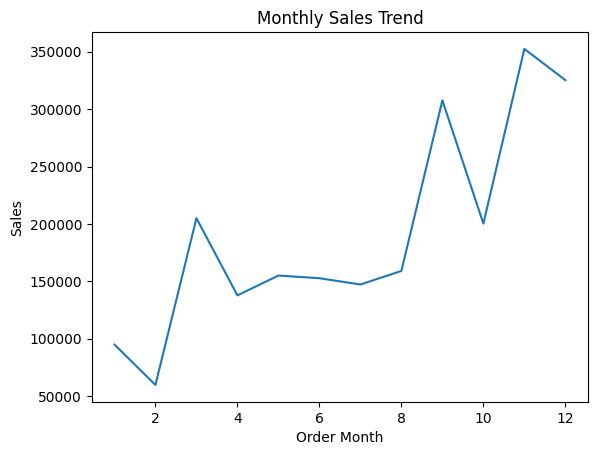

In [50]:
## Sales by Month
monthly_sales = df.groupby(["Order Month"])["Sales"].sum()
monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

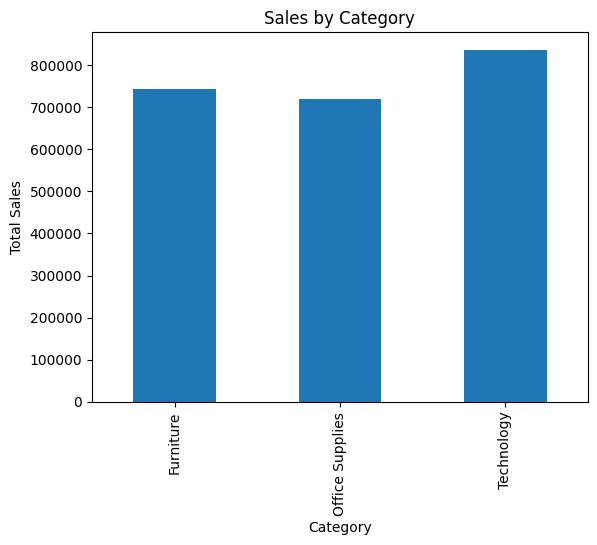

In [51]:
## Sales by Category
sales_by_category = df.groupby(["Category"])["Sales"].sum()
sales_by_category.sort_values(ascending=False)
sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

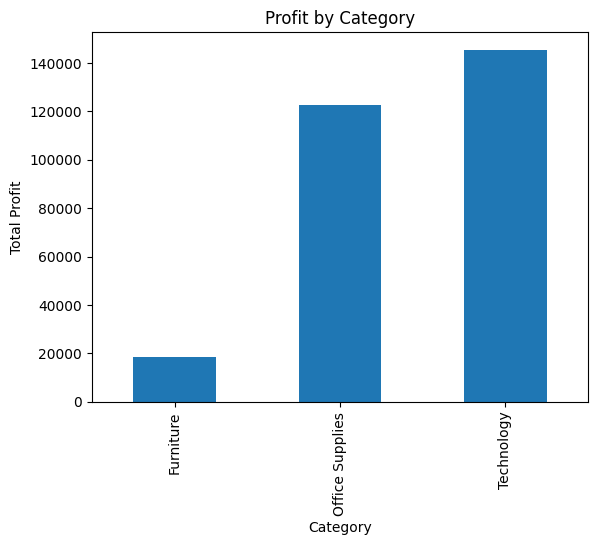

In [53]:
## Profit by Category
profit_by_category = df.groupby(["Category"])["Profit"].sum()
profit_by_category.sort_values(ascending=False)
profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.ylabel("Total Profit")
plt.show()

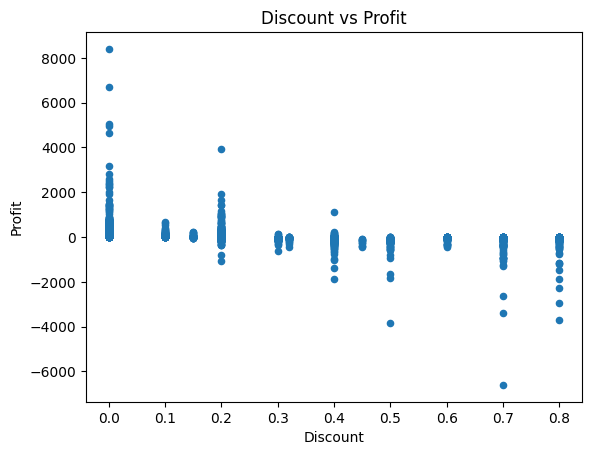

In [54]:
## Discount vs Profit
df.plot.scatter(x="Discount", y="Profit")

plt.title("Discount vs Profit")
plt.show()

# Final Business Summary

## Overview

This project analyzed sales and profitability data from a retail superstore dataset to identify key drivers of revenue and profit.

## Key Findings

### 1. Revenue Drivers
- Total Revenue: $2.29M
- Technology generated the highest sales
- Sales peak in November and December, showing strong seasonality

### 2. Profitability Issues
- Furniture produced strong revenue but weak profit
- One segment (Furniture–Central region) generated losses

### 3. Root Cause of Losses
Losses in Furniture–Central were caused by:

- High discount levels (30–60%)
- Negative average profit margins
- Specific unprofitable products

### 4. Key Business Insights

• Higher discounts strongly reduce profit  
• Technology is the most profitable category  
• Losses are concentrated in a small number of products  
• Most regions and categories are profitable

## Recommendations

1. Limit furniture discounts to 20% or less
2. Review pricing in the Central region
3. Re-evaluate loss-making products
4. Focus growth on Technology category

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Skills Demonstrated

- Data cleaning
- Feature engineering
- Exploratory data analysis
- Data visualization
- Business insight generation